# Analysis of the effect of interconference play on ranking methods
John S. McAlister - *Princeton University*<br>
Jack Haight - *University of Tennessee - Knoxville*<br>
Mate Szurop - *University of Tennessee - Chattenooga*<br>
<br><br>
SEC fans and B1G fans both believe that their conference is home to the best teams in college football. Here we investigate the ways that interconference play (or the lack thereof) can change how teams are ranked. The function demonstrated here are found in PairwiseComparision.py, in the same repository. 

In [74]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import PairwiseComparison as pc
import pandas as pd
import seaborn as sns

## How many interconference games is enough?
The main question at hand is how many interconference games is sufficient to be sure that our rankings are "good enough." In order to investigate this, we will generate schedules featuring two conferences with some number of conference games, $g$, and some number of interconference games, $M$. We will examine how changing $M$ can change the quality of our ranking. The first challenge is to generate a schedule and simulate play <br>
In the method simulate.py, a schedule is generated according with two conferences one with $n$ teams, the other with $m$ teams each playing $g$ conference games. Then $M$ total non-conference games are added randomly between members of opposite conferences. This schedule looks like an adjacency matrix (because it is).<br> The simulation also randomly generates team "strengths" (see Newman 2023 for more details) and based on these strengths, scores for each game are computed. In the below example conference 1 has 10 teams, conference 2 has 12 teams and there will be 

In [2]:
result = pc.simulate(10,12,10,dist = 'exp')

The score matrix looks like this

In [3]:
W=result[0]
print(W)

[[ 0  2 23  3 17  3 17 11 37 11  0  0  0  0  0  0  0  0  0  0  0  0]
 [39  0 33 21 37 19 35 33 39 31  0 30  0  0 25  0  0  0  0  0 24  0]
 [24  3  0  9 15  5 25 13 38 18  2  0  0  0  0  0  0  0  0  4  0  0]
 [34 13 36  0 34 12 35 26 40 25  0  0  0  0  0  0  0  0  0  0  0  0]
 [25  6 22  6  0  7 27 10 39 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [38 22 37 28 37  0 34 37 40 34  0  0  0  0  0 38  0  0  0  0  0 31]
 [14  5 14  7 11  1  0 11 37 12  5  0  0  0  0  0  0  0  0  0  0  0]
 [27  9 30 15 26  5 35  0 40 24  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  3  0  1  0  1  2  0  2  0  0  0  0  0  0  0  0  0  0  0  0]
 [20  3 23 12 22  5 31 20 38  0  0  0  0  0  0  0  0  0  0  0  5  0]
 [ 0  0 36  0  0  0 37  0  0  0  0 35 36 32  0 38 24 31 23 15  0 37]
 [ 0 11  0  0  0  0  0  0  0  0  4  0 11 18  6 32  0 12  0 11  7 16]
 [ 0  0  0  0  0  0  0  0  0  0 14 21  0  0 22 38  0 27 18  9 18 28]
 [ 0  0  0  0  0  0  0  0  0  0  5 23  0  0 13 30 10 19 13  0 17 22]
 [ 0 21  0  0  0  0  0  0  0  0  0

and the strengths look like this

In [4]:
tp = result[1]
print(tp)

[0.19265157 1.77128695 0.23974576 1.06805644 0.27359261 2.16400514
 0.17322639 0.52044279 0.01340438 0.36088454 2.60853299 0.43072119
 0.9765003  0.58139565 1.14484095 0.11862064 1.98683634 0.64343087
 1.70965055 2.45008405 1.33517683 0.52066114]


Having the strengths like this means that we can give each team a rank which is the "base truth" we will see how well our ranking algorithm can recover this base truth. Below is listed the rank of each team (teams 1-10 are in conference 1 and teams 11-22 are in conference 2)

In [5]:
truerank = np.argsort(np.argsort(tp))
print(truerank)

[ 3 17  4 13  5 19  2  8  0  6 21  7 12 10 14  1 18 11 16 20 15  9]


Now we can run the rank algorithm to try to see if we can recover this base truth from the randomly generated score matrix. 

In [6]:
rankingZer = pc.RankZermelo(W)
info = 5
initialELO = 1500 +info*np.random.normal(10*tp,1,len(tp))
rankingELO = pc.RankELO(W,initialELO)
foundrankZer = np.argsort(rankingZer)
foundrankELO = np.argsort(rankingELO)
print(foundrankZer)
print(foundrankELO)

[ 3 19  4 14  5 21  2  9  0  6 20  7 12 10 13  1 17 11 16 18 15  8]
[ 5 20  6 14  9 21  3 13  0 11 18  1 10  7 12  2 16  4 17 19 15  8]


Now we want to compare the two rankings. There are many ways that we can do that. Right now, we have implemented L1 distance, but we may also be interested to know if the top team, top 4 teams, or top 12 teams were found correctly in the right order

In [7]:
print(truerank)
print(foundrankZer)
print(foundrankELO)
print('L1 distance')
print(pc.L1dist(truerank,foundrankZer))
print(pc.L1dist(truerank,foundrankELO))
print('Did we find the top team?')
print(pc.correct_winner(truerank,foundrankZer))
print(pc.correct_winner(truerank,foundrankELO))
print('Did we find the top 4 teams?')
print(pc.correct_top_four(truerank,foundrankZer))
print(pc.correct_top_four(truerank,foundrankELO))
print('Did we find the top 12 teams?')
print(pc.correct_top_12(truerank,foundrankZer))
print(pc.correct_top_12(truerank,foundrankELO))

[ 3 17  4 13  5 19  2  8  0  6 21  7 12 10 14  1 18 11 16 20 15  9]
[ 3 19  4 14  5 21  2  9  0  6 20  7 12 10 13  1 17 11 16 18 15  8]
[ 5 20  6 14  9 21  3 13  0 11 18  1 10  7 12  2 16  4 17 19 15  8]
L1 distance
0.5454545454545454
2.4545454545454546
Did we find the top team?
True
True
Did we find the top 4 teams?
True
False
Did we find the top 12 teams?
False
False


## Changing the number of interconference games

Now lets see what how these distance metrics change as we very the number of interconference games

c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:132: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df,newrow])
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:19: RuntimeWarning: invalid value encountered in divide
  nummat = np.divide(W,pimat) # get matrix of w_{i,j}/(pi_i+pi_j)
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:20: RuntimeWarning: invalid value encountered in divide
  denommat = np.divide(W.transpose(),pimat) #get matrix of w_{j,i}/(pi_1+pi_j)


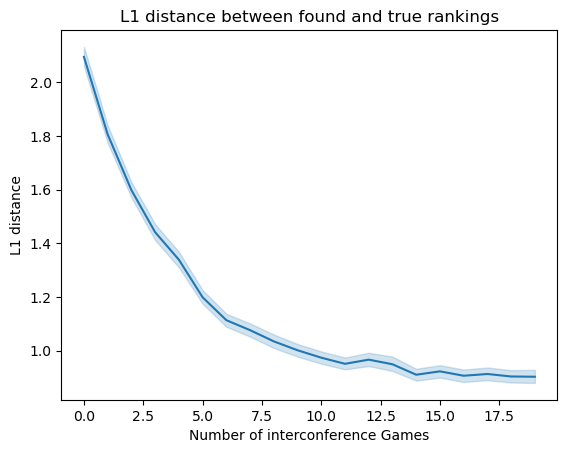

In [8]:
dfZer = pc.scanZer(10,12,0,20,reps = 5000)
ax = sns.lineplot(data=dfZer, x='M', y='LD')
plt.xlabel('Number of interconference Games')
plt.ylabel('L1 distance')
plt.title('L1 distance between found and true rankings')
plt.show()

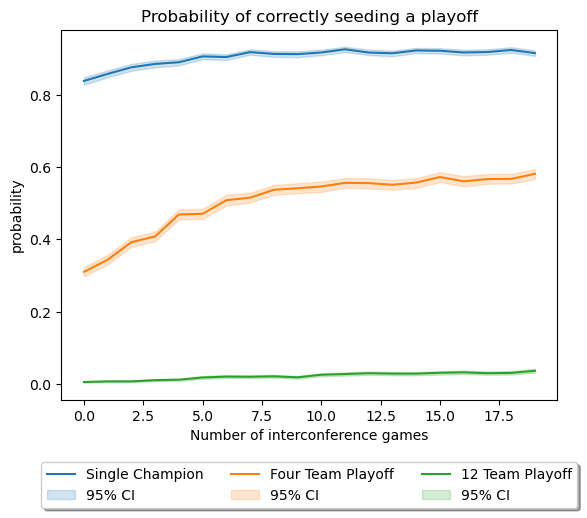

In [9]:
fig = plt.figure
ax = plt.subplot(111)
line1 = sns.lineplot(data=dfZer, x='M', y='CW')
line2 = sns.lineplot(data=dfZer, x='M', y='CT4')
line3 = sns.lineplot(data=dfZer, x='M', y='CT12')
ax.set(xlabel='Number of interconference games', ylabel ='probability', title = 'Probability of correctly seeding a playoff')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=3,labels=["Single Champion","95% CI","Four Team Playoff","95% CI","12 Team Playoff","95% CI"])

We can do the same with the ELO ranking method but we find that it is the quality of information that has much more power over the quality of the rankings than the mnodularity in the reasonable range

In [18]:
dfELO105 = pc.scanELO(10,12,0,20,reps =200,spread=100)
dfELO205 = pc.scanELO(10,12,0,20,reps =200,spread=200)
dfELO305 = pc.scanELO(10,12,0,20,reps =200,spread=300)
dfELO405 = pc.scanELO(10,12,0,20,reps =200,spread=400)
dfELO1075 = pc.scanELO(10,12,0,20,reps =200,spread=100,info=0.75)
dfELO2075 = pc.scanELO(10,12,0,20,reps =200,spread=200,info=0.75)
dfELO3075 = pc.scanELO(10,12,0,20,reps =200,spread=300,info=0.75)
dfELO4075 = pc.scanELO(10,12,0,20,reps =200,spread=400,info=0.75)
dfELO1025 = pc.scanELO(10,12,0,20,reps =200,spread=100,info = 0.25)
dfELO2025 = pc.scanELO(10,12,0,20,reps =200,spread=200,info = 0.25)
dfELO3025 = pc.scanELO(10,12,0,20,reps =200,spread=300,info = 0.25)
dfELO4025 = pc.scanELO(10,12,0,20,reps =200,spread=400,info = 0.25)


c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df,newrow])
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df,newrow])
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:147: FutureWarning: The behavior of DataFrame concatenation w

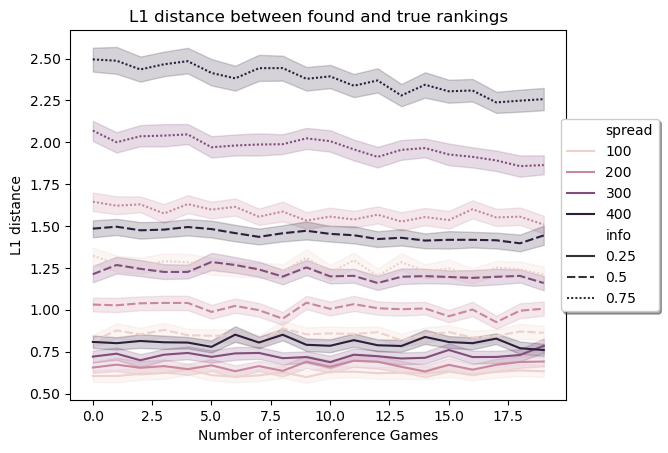

In [30]:

dfELOCombo = pd.concat([dfELO105,dfELO205,dfELO305,dfELO405,dfELO1075,dfELO2075,dfELO3075,dfELO4075,dfELO1025,dfELO2025,dfELO3025,dfELO4025])
ax = sns.lineplot(data=dfELOCombo, x='M', y='LD', hue="spread", style="info")
plt.xlabel('Number of interconference Games')
plt.ylabel('L1 distance')
plt.title('L1 distance between found and true rankings')

ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5),
          fancybox=True, shadow=True, ncol=1)
plt.show()

## Bias

We are interested to know, if there is a bias and one conference can outperform the other on average, do these pairwise comparisons break down? We will rerun the same experiment with different biases


c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:132: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df,newrow])
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:19: RuntimeWarning: invalid value encountered in divide
  nummat = np.divide(W,pimat) # get matrix of w_{i,j}/(pi_i+pi_j)
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:20: RuntimeWarning: invalid value encountered in divide
  denommat = np.divide(W.transpose(),pimat) #get matrix of w_{j,i}/(pi_1+pi_j)
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:132: FutureWarning: The behavior of 

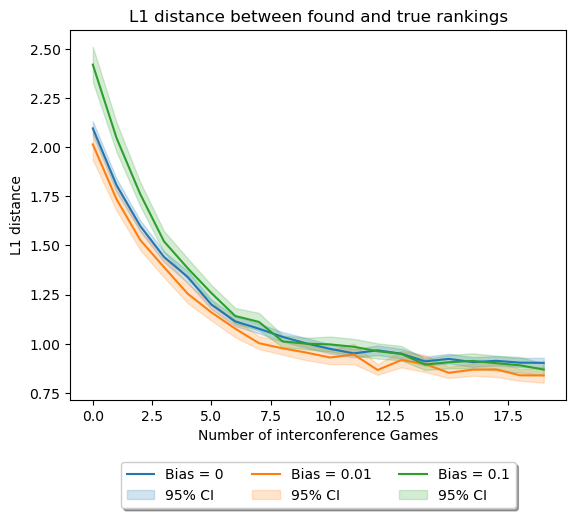

In [31]:
dfZer0=dfZer

dfZer01 = pc.scanZer(10,12,0,20,reps = 1000,bias = 0.01)

dfZer1 = pc.scanZer(10,12,0,20,reps = 1000,bias = 0.1)


ax = sns.lineplot(data=dfZer0, x='M', y='LD')
ax = sns.lineplot(data=dfZer01, x='M', y='LD')
ax = sns.lineplot(data=dfZer1, x='M', y='LD')
plt.xlabel('Number of interconference Games')
plt.ylabel('L1 distance')
plt.title('L1 distance between found and true rankings')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=3,labels=["Bias = 0","95% CI","Bias = 0.01","95% CI","Bias = 0.1","95% CI"])
plt.show()

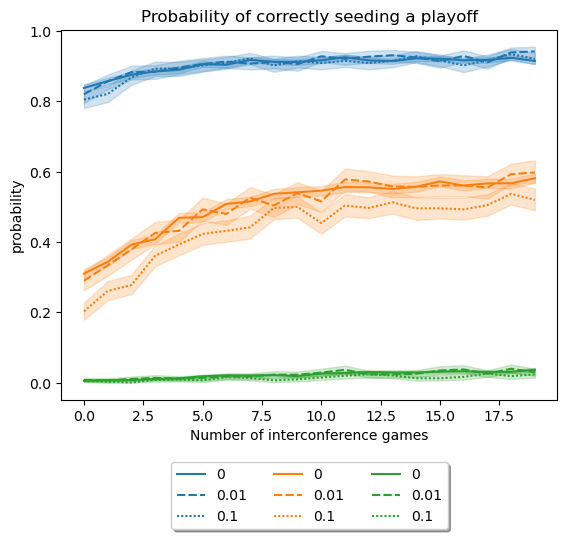

In [33]:
dfZer =pd.concat([dfZer0,dfZer01,dfZer1])
fig = plt.figure
ax = plt.subplot(111)
line1 = sns.lineplot(data=dfZer, x='M', y='CW',style = "b")
line2 = sns.lineplot(data=dfZer, x='M', y='CT4',style = "b")
line3 = sns.lineplot(data=dfZer, x='M', y='CT12', style = "b")
ax.set(xlabel='Number of interconference games', ylabel ='probability', title = 'Probability of correctly seeding a playoff')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
         fancybox=True, shadow=True, ncol=3 )

Again we can do the same with the ELO model

c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:140: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df,newrow])
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:140: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df,newrow])


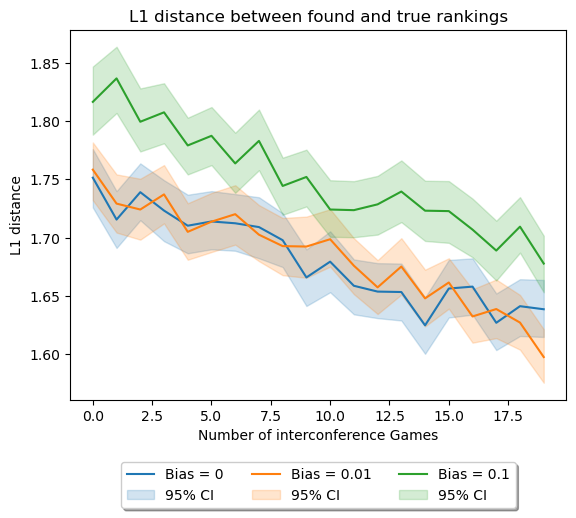

In [ ]:
dfELO0=dfELO

dfELO01 = pc.scanELO(10,12,0,20,reps = 1000,bias = 0.01,spread = 500)

dfELO1 = pc.scanELO(10,12,0,20,reps = 1000,bias = 0.1,spread = 500)


ax = sns.lineplot(data=dfELO0, x='M', y='LD')
ax = sns.lineplot(data=dfELO01, x='M', y='LD')
ax = sns.lineplot(data=dfELO1, x='M', y='LD')
plt.xlabel('Number of interconference Games')
plt.ylabel('L1 distance')
plt.title('L1 distance between found and true rankings')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=3,labels=["Bias = 0","95% CI","Bias = 0.01","95% CI","Bias = 0.1","95% CI"])
plt.show()

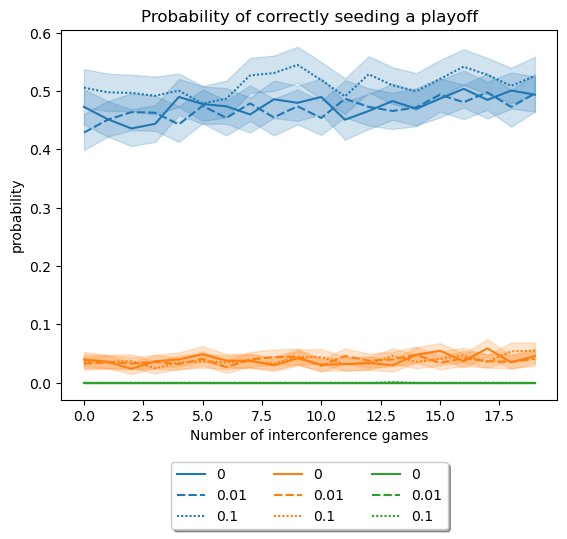

In [ ]:
dfELO =pd.concat([dfELO0,dfELO01,dfELO1])
fig = plt.figure
ax = plt.subplot(111)
line1 = sns.lineplot(data=dfELO, x='M', y='CW',style = "b")
line2 = sns.lineplot(data=dfELO, x='M', y='CT4',style = "b")
line3 = sns.lineplot(data=dfELO, x='M', y='CT12', style = "b")
ax.set(xlabel='Number of interconference games', ylabel ='probability', title = 'Probability of correctly seeding a playoff')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
         fancybox=True, shadow=True, ncol=3)

# Emperical distribution

ValueError: p < 0, p > 1 or p contains NaNs

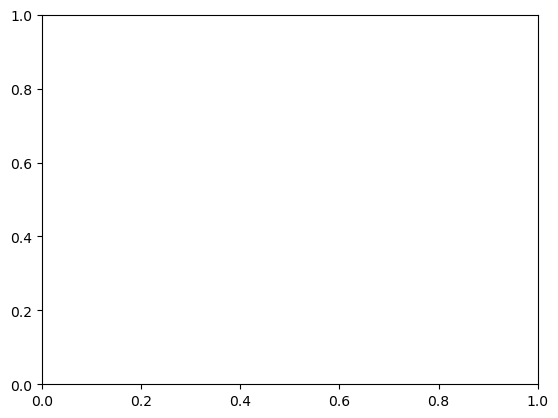

In [ ]:
fig = plt.figure
ax = plt.subplot(111)
for i in range(1,10):
    d=pc.difDistribution(16,18,i,t=-1,reps=2000,comp=True)
    [x,y]=pc.get_ecdf(d)
    plt.plot(x,y,label = i)
ax.set_title("CDF of error in average difference between conference strengths")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
         fancybox=True, shadow=True, ncol=5, title = "Number of Interconference Games")
plt.show()

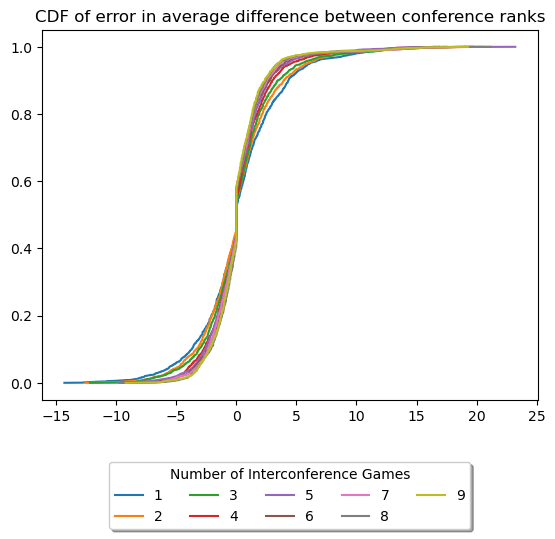

In [53]:
fig = plt.figure
ax = plt.subplot(111)
for i in range(1,10):
    d=pc.difRankDistribution(14,16,i,t=-1,reps=2000,comp=True)
    [x,y]=pc.get_ecdf(d)
    plt.plot(x,y,label = i)
ax.set_title("CDF of error in average difference between conference ranks")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
         fancybox=True, shadow=True, ncol=5, title = "Number of Interconference Games")
plt.show()

c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:19: RuntimeWarning: invalid value encountered in divide
  nummat = np.divide(W,pimat) # get matrix of w_{i,j}/(pi_i+pi_j)
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:20: RuntimeWarning: invalid value encountered in divide
  denommat = np.divide(W.transpose(),pimat) #get matrix of w_{j,i}/(pi_1+pi_j)


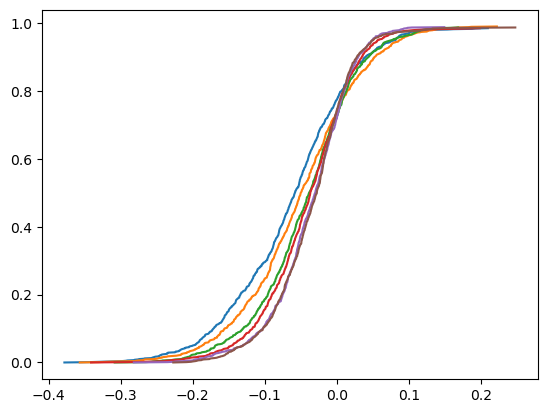

In [55]:
fig = plt.figure
ax = plt.subplot(111)
for i in range(1,7):
    d=pc.difDistribution(14,16,i,t=5,reps=1000,bias = 0.1,comp= True)
    [x,y]=pc.get_ecdf(d)
    plt.plot(x,y,label = i)
plt.show()

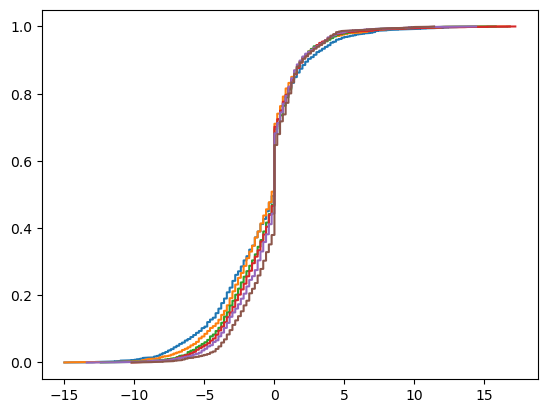

In [58]:
fig = plt.figure
ax = plt.subplot(111)
for i in range(1,7):
    d=pc.difRankDistribution(14,16,i,t=5,reps=2000,bias = 0.1,comp=True)
    [x,y]=pc.get_ecdf(d)
    plt.plot(x,y,label = i)
plt.show()

## Emperical Hypothesis test
Last season the average rank of the top five SEC teams was 6.8 and the average rank of the top five Big10 teams was 8.4 for a difference of 1.6. It is clear that from the emperical CDF demonstrateed above, this is an exceedingly reasonable difference between conferences. The odds of this happening by chance under the null hypothesis that the two conferences are, on average, equal is calculated below

In [75]:
d=pc.difRankDistribution(16,18,3,t=5,reps=5000,bias = 0,comp=True)


c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:19: RuntimeWarning: invalid value encountered in divide
  nummat = np.divide(W,pimat) # get matrix of w_{i,j}/(pi_i+pi_j)
c:\Users\jonmc\Documents\Research\PairwiseComparison\InterconferencePlay\PairwiseComparison.py:20: RuntimeWarning: invalid value encountered in divide
  denommat = np.divide(W.transpose(),pimat) #get matrix of w_{j,i}/(pi_1+pi_j)


In [76]:
[x,y]=pc.get_ecdf(d)
idx =np.argmax(x>-1.6)
p=y[idx]
print(p)
idx =np.argmax(x>1.6)
p=p+(1-y[idx])
print("The probability that the difference in average ranks between the top five teams in each conference is at least 1.6 is {}".format(p))
print("There is certainly not enough evidence to reject the hypothesis that the two conferences are equally competative at the top of the conference")



0.1870374074814963
The probability that the difference in average ranks between the top five teams in each conference is at least 1.6 is 0.3922784556911383
There is certainly not enough evidence to reject the hypothesis that the two conferences are equally competative at the top of the conference


This may play into the argument that the Big10 is top heavy but the SEC is better throughout. Lets next investigate this claim by looking at the CBS rankings of all 138 teams at the end of the 2025 regular season. If we condense this list only the 34 teams in the big10 or SEC then we see that the average rank in the SEC is 16.05 and the average rank in the Big10 is 18.94 so the differenced is 2.88 and the probability that such a difference happens under the null hypothesis is approximated below

In [77]:
d=pc.difRankDistribution(16,18,3,t=-1,reps=5000,bias = 0,comp = True)


In [78]:
[x,y]=pc.get_ecdf(d)
idx =np.argmax(x>-2.88)
ptemp=y[idx]
idx =np.argmax(x>2.88)
p=ptemp+(1-y[idx])
print("The probability that the difference in average ranks is at least 2.88 is {}".format(p))
print("If we are testing the hypothesis specifically that the SEC is better than the big 10 there is a {}% percent chance that such a difference occurs in favor of the SEC specifically".format(ptemp*100))
print("There is certainly not enough evidence to reject the hypothesis that the two conferences are equally competative")

The probability that the difference in average ranks is at least 2.88 is 0.27585517103420676
If we are testing the hypothesis specifically that the SEC is better than the big 10 there is a 12.682536507301458% percent chance that such a difference occurs in favor of the SEC specifically
There is certainly not enough evidence to reject the hypothesis that the two conferences are equally competative
